In [1]:
import cv2
from matplotlib import pyplot
import numpy

# Ustawienie rozmarów wyświetlanych obrazów
pyplot.rcParams["figure.figsize"] = (18, 10)

In [2]:
#
# Wczytanie obrazów źródłowych
#
# źródło grafiki colors.jpg: https://unsplash.com/photos/gT5kuls6Y6Q
# źródło grafiki gacław-na-kuchni.jpg: własne
#
#image_from_file = cv2.imread('images/colors.jpg')
image_from_file = cv2.imread('images/gacław-na-kuchni.jpg')
image_gray = cv2.cvtColor(image_from_file, cv2.COLOR_BGR2GRAY)
image_color = cv2.cvtColor(image_from_file, cv2.COLOR_BGR2RGB)
print('Rozmiar obrazka: ', image_from_file.shape)

Rozmiar obrazka:  (768, 1024, 3)


# Zadanie 1

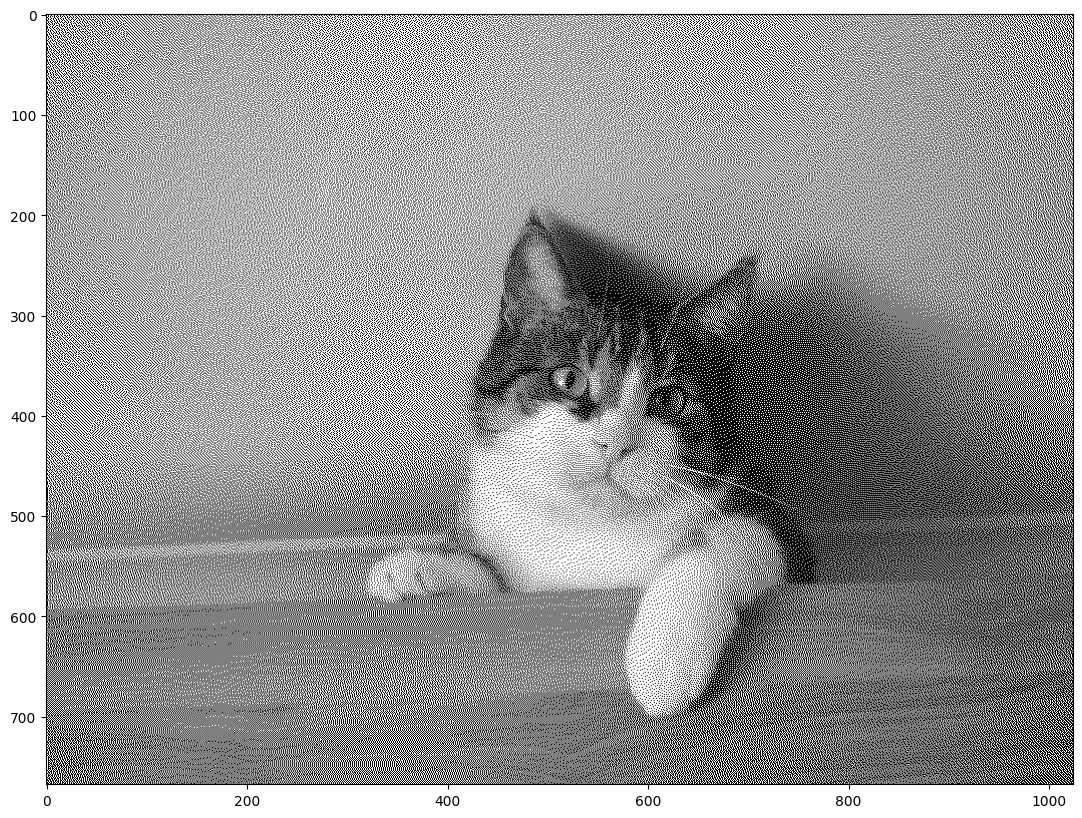

In [3]:
output = numpy.copy(image_gray).astype(numpy.float32)

#
# Funkcja redukcji palety barw dla skali szarości (2 wartości: 0, 255)
#
def find_closest_palette_color_grayscale(value):
    return round(value / 255) * 255

#
# Algorytm Floyd-Steinberga dla skali szarości
#
for y in range(output.shape[0]):
    for x in range(output.shape[1]):
        oldpixel = output[y, x]
        newpixel = find_closest_palette_color_grayscale(oldpixel)
        output[y, x] = newpixel
        quant_error = oldpixel - newpixel
        
        # Rozprzestrzeń błędu do sąsiednich pikseli
        # Prawo: (x+1, y)
        if x + 1 < output.shape[1]:
            output[y, x + 1] = numpy.clip(output[y, x + 1] + quant_error * 7 / 16, 0, 255)
        
        # Lewo-dół: (x-1, y+1)
        if y + 1 < output.shape[0] and x - 1 >= 0:
            output[y + 1, x - 1] = numpy.clip(output[y + 1, x - 1] + quant_error * 3 / 16, 0, 255)
        
        # Dół: (x, y+1)
        if y + 1 < output.shape[0]:
            output[y + 1, x] = numpy.clip(output[y + 1, x] + quant_error * 5 / 16, 0, 255)
        
        # Prawo-dół: (x+1, y+1)
        if y + 1 < output.shape[0] and x + 1 < output.shape[1]:
            output[y + 1, x + 1] = numpy.clip(output[y + 1, x + 1] + quant_error * 1 / 16, 0, 255)

output = output.astype(numpy.uint8)

#
# Wyświetlenie
#
pyplot.imshow(output, cmap='gray')

Text(0, 0.5, 'Liczba pikseli obrazu []')

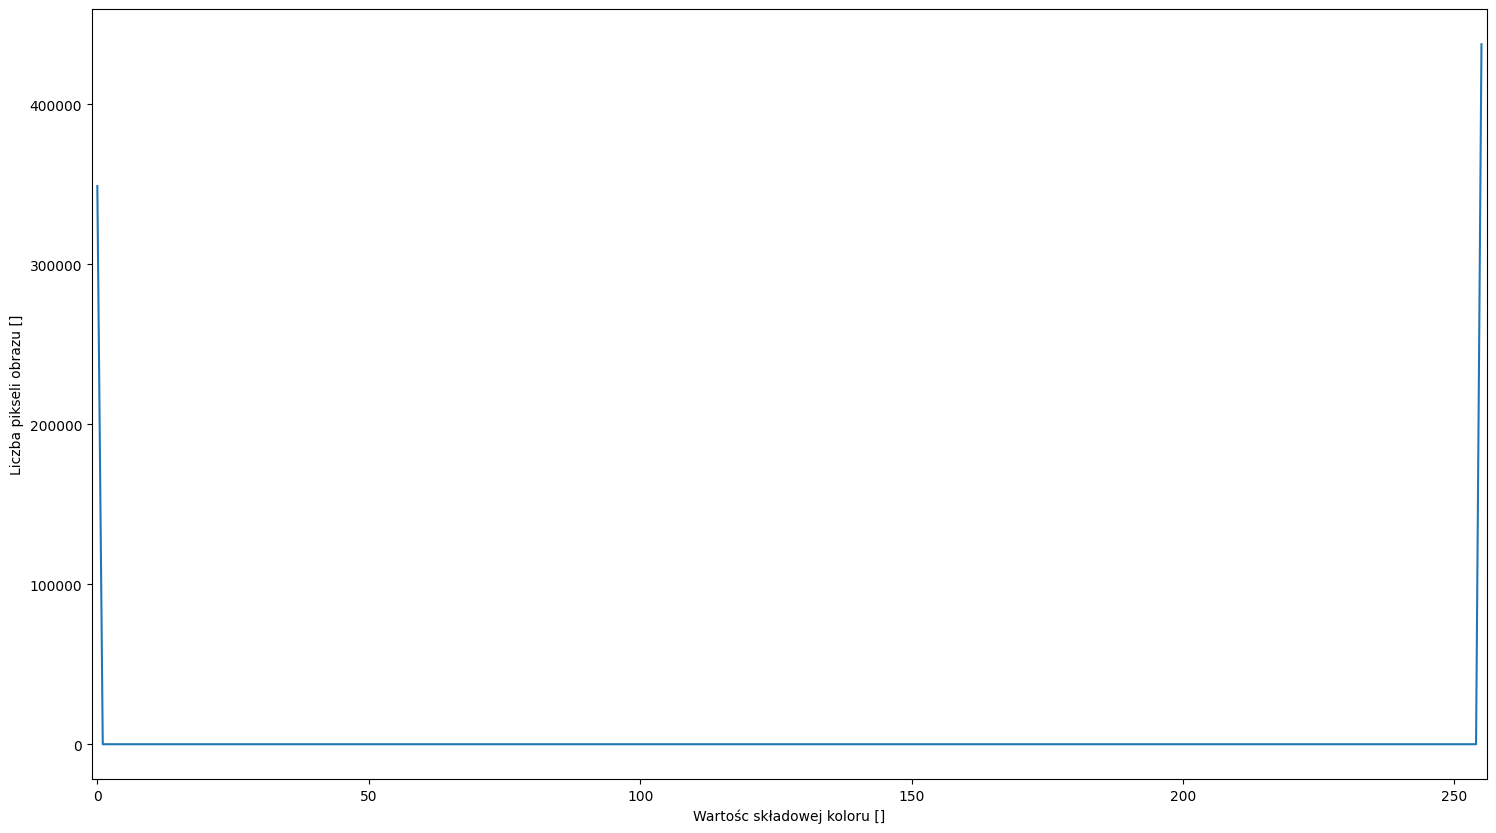

In [4]:
#
# Histogram
#
histr = cv2.calcHist([output], [0], None, [256], [0, 256])
pyplot.plot(histr)
pyplot.xlim([-1, 256])
pyplot.xlabel('Wartośc składowej koloru []')
pyplot.ylabel('Liczba pikseli obrazu []')

# Zadanie 2

Text(0.5, 1.0, 'Dithering Floyd-Steinberga (k=2)')

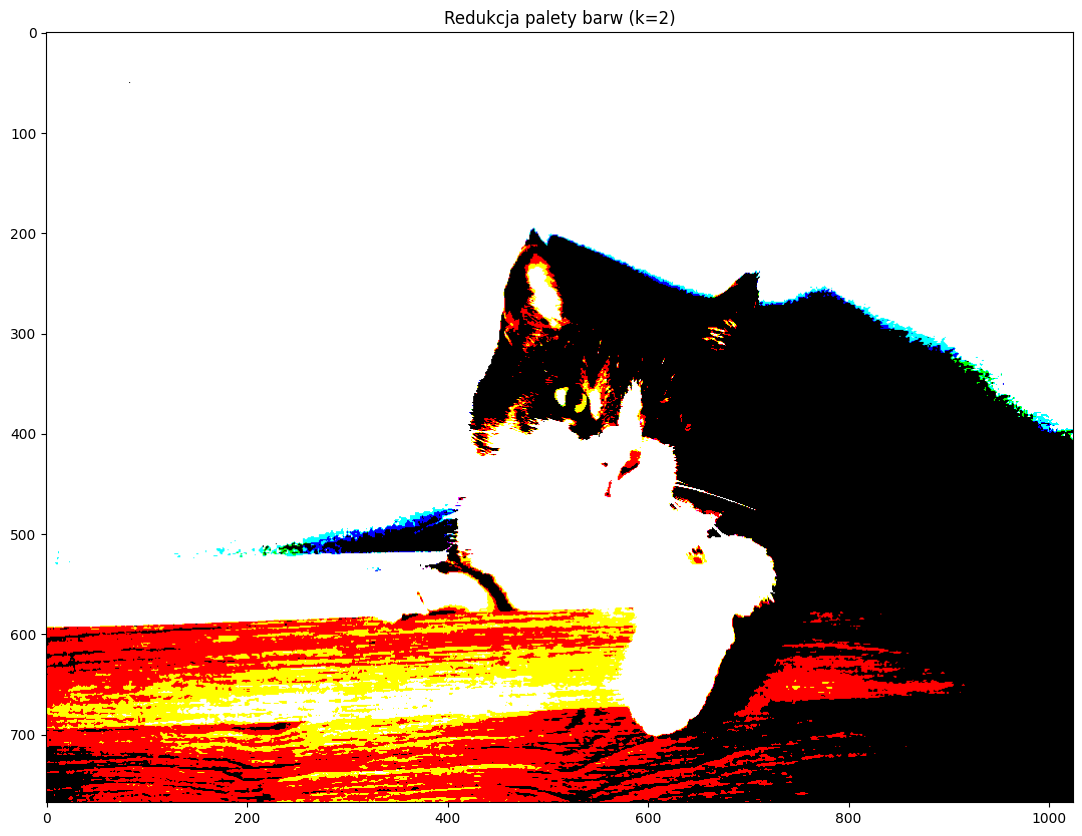

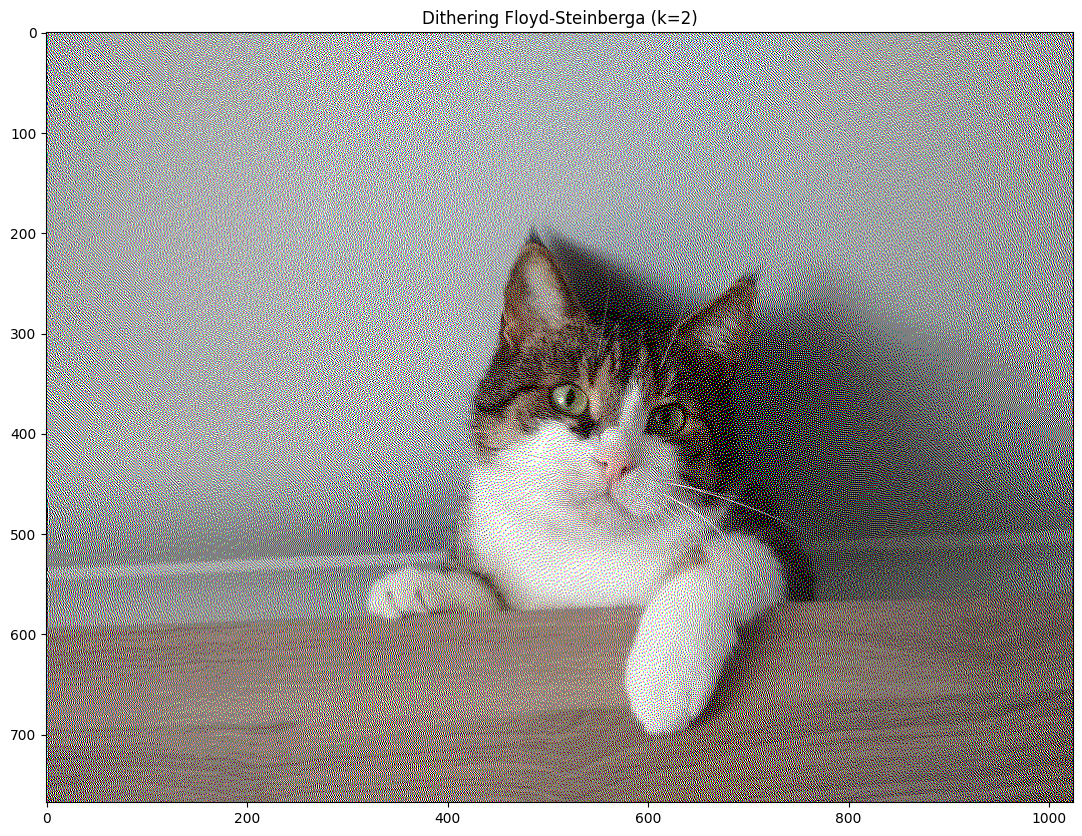

In [5]:
output_reduced = numpy.copy(image_color).astype(numpy.uint8)
k = 2  # Liczba wartości na składową (domyślnie 2: 0 i 255)

#
# Funkcja redukcji palety barw dla koloru
#
def find_closest_palette_color_rgb(value, k):
    if k == 2:
        return round(value / 255) * 255
    else:
        return round((k - 1) * value / 255) * 255 / (k - 1)

#
# Wyświetlenie obrazka po redukcji barw (bez ditheringu)
#
pyplot.figure()
for y in range(output_reduced.shape[0]):
    for x in range(output_reduced.shape[1]):
        for c in range(3):
            output_reduced[y, x, c] = find_closest_palette_color_rgb(output_reduced[y, x, c], k)
pyplot.imshow(output_reduced)
pyplot.title(f'Redukcja palety barw (k={k})')

#
# Algorytm Floyd-Steinberga dla koloru
#
output = numpy.copy(image_color).astype(numpy.float32)

for y in range(output.shape[0]):
    for x in range(output.shape[1]):
        for c in range(3):  # RGB
            oldpixel = output[y, x, c]
            newpixel = find_closest_palette_color_rgb(oldpixel, k)
            output[y, x, c] = newpixel
            quant_error = oldpixel - newpixel
            
            # Rozprzestrzeń błędu do sąsiednich pikseli
            # Prawo: (x+1, y)
            if x + 1 < output.shape[1]:
                output[y, x + 1, c] = numpy.clip(output[y, x + 1, c] + quant_error * 7 / 16, 0, 255)
            
            # Lewo-dół: (x-1, y+1)
            if y + 1 < output.shape[0] and x - 1 >= 0:
                output[y + 1, x - 1, c] = numpy.clip(output[y + 1, x - 1, c] + quant_error * 3 / 16, 0, 255)
            
            # Dół: (x, y+1)
            if y + 1 < output.shape[0]:
                output[y + 1, x, c] = numpy.clip(output[y + 1, x, c] + quant_error * 5 / 16, 0, 255)
            
            # Prawo-dół: (x+1, y+1)
            if y + 1 < output.shape[0] and x + 1 < output.shape[1]:
                output[y + 1, x + 1, c] = numpy.clip(output[y + 1, x + 1, c] + quant_error * 1 / 16, 0, 255)

output = output.astype(numpy.uint8)


pyplot.figure()
pyplot.imshow(output)
pyplot.title(f'Dithering Floyd-Steinberga (k={k})')

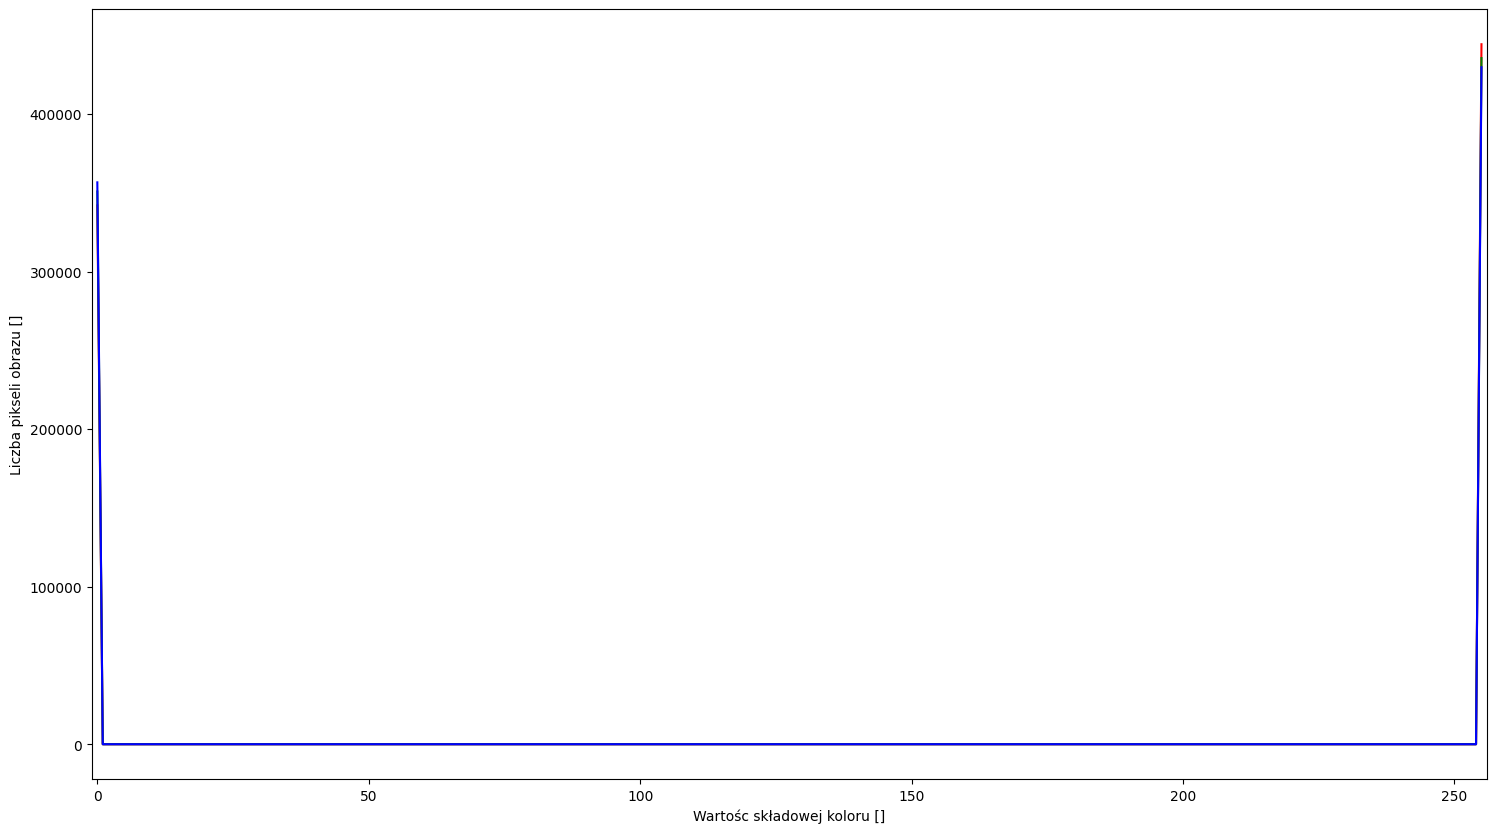

In [7]:
#
# Histogram
#
color = ('r', 'g', 'b')

for i, col in enumerate(color):
    histr = cv2.calcHist([output], [i], None, [256], [0, 256])
    pyplot.plot(histr, color=col)
    pyplot.xlim([-1, 256])
    pyplot.xlabel('Wartośc składowej koloru []')
    pyplot.ylabel('Liczba pikseli obrazu []')

# Zadanie 3

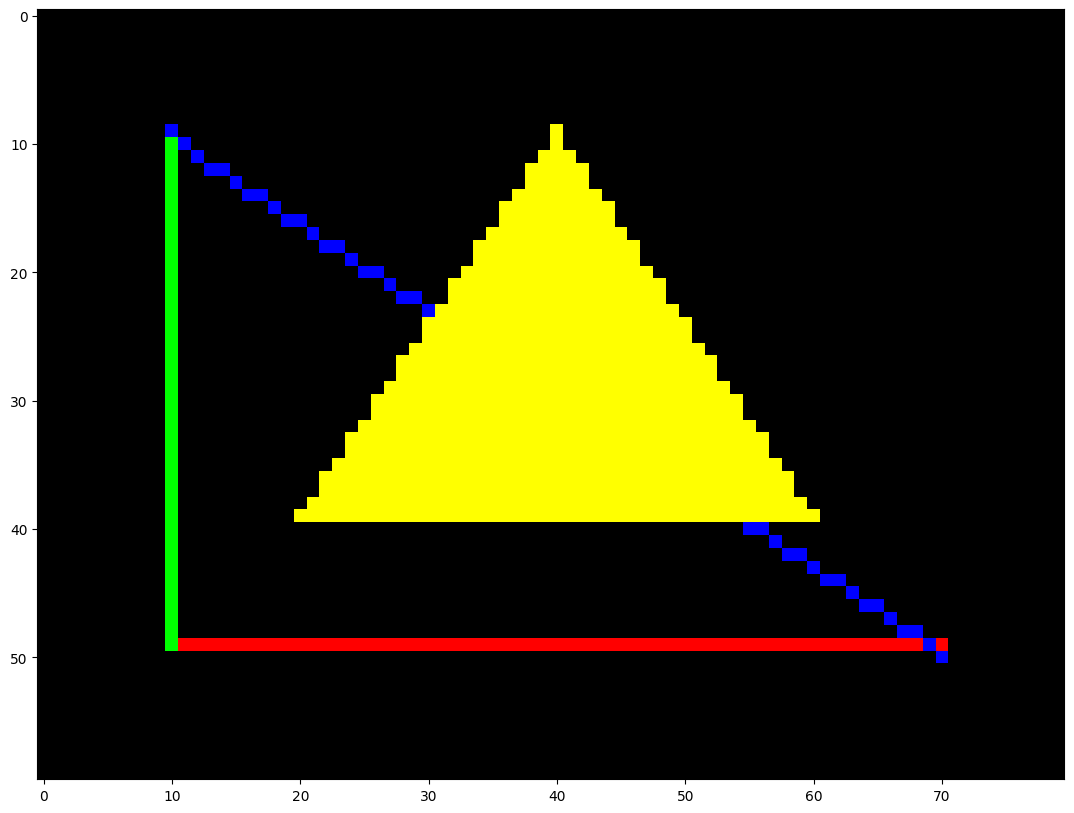

In [6]:
#
# Przygotowanie płótna
#
width = 80
height = 60
image = numpy.zeros((height, width, 3), dtype=numpy.uint8)


#
# Funkcja rysująca punkt
def draw_point(image, x, y, color=(255, 255, 255)):
    if 0 <= x < image.shape[1] and 0 <= y < image.shape[0]:
        image[image.shape[0] - 1 - y, x, :] = color


#
# Funkcja rysująca linię - algorytm Bresenhama
#
def draw_line(image, x1, y1, x2, y2, color=(255, 255, 255)):
    # Wyznaczenie wielkości pomocniczych
    dx = abs(x2 - x1)
    dy = abs(y2 - y1)
    xi = 1 if x2 - x1 > 0 else (-1 if x2 - x1 < 0 else 0)
    yi = 1 if y2 - y1 > 0 else (-1 if y2 - y1 < 0 else 0)
    
    # Początkowa wartość błędu i liczba kroków
    if dx > dy:
        d = 2 * dy - dx
        steps = dx
    else:
        d = 2 * dx - dy
        steps = dy
    
    x, y = x1, y1
    
    # Rysowanie linii - użyj for zamiast while True
    for _ in range(steps + 1):
        draw_point(image, x, y, color)
        
        # Krok w kierunku dominującym
        if dx > dy:
            x += xi
            d += 2 * dy
            if d >= 0:
                y += yi
                d -= 2 * dx
        else:
            y += yi
            d += 2 * dx
            if d >= 0:
                x += xi
                d -= 2 * dy


#
# Funkcja obliczająca pole trójkąta (iloczyn wektorowy 2D)
#
def triangle_area(ax, ay, bx, by, cx, cy):
    return (cx - ax) * (by - ay) - (cy - ay) * (bx - ax)


#
# Funkcja rysująca trójkąt
#
def draw_triangle(image, a, b, c, color=(255, 255, 255)):
    # a, b, c to krotki (x, y)
    ax, ay = a
    bx, by = b
    cx, cy = c
    
    # Wyznaczenie bounding box
    xmin = max(0, int(min(ax, bx, cx)))
    xmax = min(image.shape[1] - 1, int(max(ax, bx, cx)))
    ymin = max(0, int(min(ay, by, cy)))
    ymax = min(image.shape[0] - 1, int(max(ay, by, cy)))
    
    # Pole całego trójkąta
    area = triangle_area(ax, ay, bx, by, cx, cy)
    
    # Iteracja przez piksele w bounding box
    for y in range(ymin, ymax + 1):
        for x in range(xmin, xmax + 1):
            # Obliczenie pól trzech trójkątów
            area0 = triangle_area(ax, ay, bx, by, x, y)
            area1 = triangle_area(bx, by, cx, cy, x, y)
            area2 = triangle_area(cx, cy, ax, ay, x, y)
            
            # Sprawdzenie czy punkt należy do trójkąta
            if (area0 >= 0 and area1 >= 0 and area2 >= 0) or (area0 <= 0 and area1 <= 0 and area2 <= 0):
                draw_point(image, x, y, color)


#
# Rysowanie
#
draw_line(image, 10, 10, 70, 10, color=(255, 0, 0))      # Czerwona linia pozioma
draw_line(image, 10, 10, 10, 50, color=(0, 255, 0))      # Zielona linia pionowa
draw_line(image, 10, 50, 70, 10, color=(0, 0, 255))      # Niebieska linia ukośna
draw_triangle(image, (20, 20), (40, 50), (60, 20), color=(255, 255, 0))  # Żółty trójkąt

#
# Wyświetlenie
#
pyplot.imshow(image)

# Zadanie 4

In [ ]:
#
# Przygotowanie płótna
#
width = 80
height = 60
image = numpy.zeros((height, width, 3), dtype=numpy.uint8)


#
# Funkcja rysująca punkt
#
# NOTE(sdatko): punkt 0,0 to lewy dolny róg obrazu
#
def draw_point(image, x, y, color=(255, 255, 255)):
    image[image.shape[0] - 1 - y, x, :] = color


#
# Funkcja rysująca linię
#
def draw_line(image, x1, y1, x2, y2):
    pass  # TODO: implement


#
# Funkcja rysująca trójkąt
#
def draw_triangle(image, a, b, c):
    pass  # TODO: implement


#
# Rysowanie
#
pass  # TODO: implement

#
# Wyświetlenie
#
pyplot.imshow(image)

# Zadanie 5

In [ ]:
#
# Przygotowanie płótna
#
width = 80
height = 60
image = numpy.zeros((height, width, 3), dtype=numpy.uint8)


#
# Funkcja rysująca punkt
#
# NOTE(sdatko): punkt 0,0 to lewy dolny róg obrazu
#
def draw_point(image, x, y, color=(255, 255, 255)):
    image[image.shape[0] - 1 - y, x, :] = color


#
# Funkcja rysująca linię
#
def draw_line(image, x1, y1, x2, y2):
    pass  # TODO: implement


#
# Funkcja rysująca trójkąt
#
def draw_triangle(image, a, b, c):
    pass  # TODO: implement


#
# Rysowanie
#
pass  # TODO: implement

#
# Wyświetlenie
#
pyplot.imshow(image)